In [2]:
import os
import random
from datetime import datetime

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import BinaryClassifier as BC
import HepG2Dataset as HG2D
import my_util

In [3]:
# Declare  variables, working directory and dataset directory
MODE = 'all_features'
NUM_EPOCHS = 200
START_EPOCH = 0
NUM_ITEMS = 10_000
BATCH_SIZE = 32
DROPOUT_RATE = 0.3

L1_lambda = 0.005
L2_lambda = 0.001
# L1_lambda = 0.0
# L2_lambda = 0.0

WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank'
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/dataset'

MODEL_MODE = "dol1l2" # regular (reg), dropout (do), dropout + l1l2 (dol1l2)
PREFIX = f"{MODEL_MODE}-leakyrelu-lrscheduler-{DROPOUT_RATE}"
SUFFIX = f"{NUM_ITEMS}-{NUM_EPOCHS}-{BATCH_SIZE}-{L1_lambda}-{L2_lambda}"

CHECKPOINT_NAME = os.path.join(WORKING_DIR, 'output', 'model', MODE, "v2", f'{PREFIX}-checkpoint-{SUFFIX}.pt')

IMAGE_FILE = os.path.join(WORKING_DIR, 'output', 'img', 'train', MODE, "v2", f"{PREFIX}-ranking-{SUFFIX}.png")
TEST_FILE = os.path.join(WORKING_DIR, 'output', 'test', MODE, "v2", f"{PREFIX}-test-results-{SUFFIX}.txt")
TRAINING_FILE = os.path.join(WORKING_DIR, 'output', 'train', MODE, "v2", f"{PREFIX}-train-validation-metrics-{SUFFIX}.csv")
TEST_RESULT_FILE = os.path.join(WORKING_DIR, 'output', 'test', MODE, "v2", f"{PREFIX}-test-metrics-{SUFFIX}.csv")
ROC_FILE = os.path.join(WORKING_DIR, 'output', 'img', 'roc', MODE, "v2", f"{PREFIX}-roc-{SUFFIX}.png")
CM_FILE = os.path.join(WORKING_DIR, 'output', 'img', 'confusion_matrix', MODE, "v2", f"{PREFIX}-cm-{SUFFIX}.png")

INPUT_SIZE = 40_000

print(CHECKPOINT_NAME)

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/model/all_features/v2/dol1l2-leakyrelu-lrscheduler-0.3-checkpoint-10000-200-32-0.005-0.001.pt


In [3]:
device = my_util.get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [4]:
# Load dataset
all_features = pl.read_parquet(os.path.join(DATASET_DIR, 'features', f'{MODE}.parquet'))
all_features

index,gene_id,all_features,value_1
u32,str,list[f64],f64
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934
…,…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]",0.0
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]",0.0
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]",0.0


In [6]:
# Convert to numpy array
all_features_np = all_features.to_numpy()

In [7]:
# Split train, test, validation by index
data_indices = np.arange(len(all_features_np))
print(data_indices)

[    0     1     2 ... 22151 22152 22153]


In [8]:
# First split: 80% train, 20% temporary (for test + validation)
train_idx, temp_idx = train_test_split(
    data_indices, 
    test_size=0.2, 
    random_state=42  # For reproducibility
)

In [9]:
# Second split: Split temp_idx into 50% test and 50% validation
val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.5, 
    random_state=42  # Same random_state for consistency
)

In [10]:
print(train_idx)
print(val_idx)
print(test_idx)

[12829 12333  8225 ...  5390   860 15795]
[13202 15153  3113 ...  1158  6603 15289]
[17261  8344  1396 ...  7985   482 16493]


In [11]:
# Result: train_idx (80%), test_idx (10%), val_idx (10%)
print(f"Train indices: {len(train_idx)}")
print(f"Test indices: {len(test_idx)}")
print(f"Validation indices: {len(val_idx)}")

Train indices: 17723
Test indices: 2216
Validation indices: 2215


# Experiment

In [12]:
# Define the dataset
train_dataset = HG2D.HepG2Dataset(int(0.8 * NUM_ITEMS), all_features_np, train_idx)
val_dataset = HG2D.HepG2Dataset(int(0.1 * NUM_ITEMS), all_features_np, val_idx)
test_dataset = HG2D.HepG2Dataset(int(0.1 * NUM_ITEMS), all_features_np, test_idx)

In [13]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

8000
1000
1000


In [14]:
# Define the dataloader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

In [21]:
# Initialize model
if MODEL_MODE == "reg":
    model = BinaryClassifier(input_size=INPUT_SIZE).to(device)
elif MODEL_MODE == "do":
    model = BinaryClassifierDropOut(input_size=INPUT_SIZE, dropout_rate=DROPOUT_RATE).to(device)
elif MODEL_MODE == "dol1l2":
    model = BC.BinaryClassifierDropOutL1L2(input_size=INPUT_SIZE, dropout_rate=DROPOUT_RATE, l1_lambda=L1_lambda, l2_lambda=L2_lambda).to(device)

# Define loss function for binary classification
criterion = nn.BCELoss()  # Binary Cross Entropy Loss

# Training loop example
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

# Define learning rate scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.1)

In [22]:
print(model)

BinaryClassifierDropOutL1L2(
  (network): Sequential(
    (0): Linear(in_features=40000, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [23]:
# Arrays for saving the performance metric
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

In [24]:
# Check if the checkpoint exists
if os.path.exists(CHECKPOINT_NAME):
    checkpoint = torch.load(CHECKPOINT_NAME)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    START_EPOCH = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_accuracies = checkpoint['train_accuracies']
    val_accuracies = checkpoint['val_accuracies']
    train_aucs = checkpoint['train_aucs']
    val_aucs = checkpoint['val_aucs']
    val_precisions = checkpoint['val_precisions']
    val_recalls = checkpoint['val_recalls']
    val_f1_scores = checkpoint['val_f1_scores']

    print(f"{CHECKPOINT_NAME} exists. Resuming training from epoch {START_EPOCH}.")
else:
    START_EPOCH = 0

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/model/all_features/v2/dol1l2-leakyrelu-lrscheduler-0.3-checkpoint-10000-200-32-0.005-0.001.pt exists. Resuming training from epoch 51.


In [25]:
# Training loop
for epoch in range(START_EPOCH, NUM_EPOCHS):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_labels = []

    # Training phase
    for X_batch, y_batch in train_loader:

        if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
            outputs = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))
        elif MODEL_MODE == "dol1l2":
            outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        predictions = (outputs.squeeze(1) >= 0.5).long()

        train_loss += loss.item()
        train_correct += (predictions == y_batch.to(device)).sum().item()
        train_total += y_batch.size(0)
        
        train_true_labels.extend(y_batch.cpu().numpy())
        train_predicted_labels.extend(predictions.cpu().numpy())
        
    # # Adjust learning rate
    # scheduler.step()
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_labels)

    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            
            if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
                outputs = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))
            elif MODEL_MODE == "dol1l2":
                outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg
            
            predictions = (outputs.squeeze(1) >= 0.5).long()
            
            val_loss += loss.item()
            val_correct += (predictions == y_batch.to(dtype=torch.float32).to(device)).sum().item()
            val_total += y_batch.size(0)
            val_true_labels.extend(y_batch.cpu().numpy())
            val_predicted_labels.extend(predictions.cpu().numpy())
            
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_metric = val_correct / len(val_loader)

        # Calculate precision, recall, and F1-score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            val_true_labels, 
            val_predicted_labels, 
            average='binary'  # Use macro average for multi-class classification
        )

        val_true_labels = np.array(val_true_labels)
        val_predicted_labels = np.array(val_predicted_labels)
        val_auc_score = roc_auc_score(val_true_labels, val_predicted_labels)

        val_losses.append(round(avg_val_loss, 4))
        val_accuracies.append(round(val_accuracy, 2))
        val_aucs.append(round(val_auc_score, 2))
        val_precisions.append(round(precision, 2))
        val_recalls.append(round(recall, 2))
        val_f1_scores.append(round(f1_score, 2))

    # Adjust learning rate
    scheduler.step(val_loss)

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
          f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
          f'AUC: {val_auc_score:.2f}')
    
    # Save the model
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'train_aucs': train_aucs,
        'val_aucs': val_aucs,
        'val_precisions': val_precisions,
        'val_recalls': val_recalls,
        'val_f1_scores': val_f1_scores,
    }, CHECKPOINT_NAME)

Epoch [52/200] - [TRAIN] Loss: 0.6016, Accuracy: 71.15%, AUC: 0.71 [VAL] Loss: 0.5606, Accuracy: 73.90%, Precision: 0.76, Recall: 0.65, F1-Score: 0.70, AUC: 0.73
Epoch [53/200] - [TRAIN] Loss: 0.6118, Accuracy: 69.94%, AUC: 0.69 [VAL] Loss: 0.5948, Accuracy: 69.50%, Precision: 0.70, Recall: 0.63, F1-Score: 0.66, AUC: 0.69
Epoch [54/200] - [TRAIN] Loss: 0.6013, Accuracy: 70.45%, AUC: 0.70 [VAL] Loss: 0.6087, Accuracy: 70.30%, Precision: 0.71, Recall: 0.59, F1-Score: 0.64, AUC: 0.69
Epoch [55/200] - [TRAIN] Loss: 0.6067, Accuracy: 70.46%, AUC: 0.70 [VAL] Loss: 0.5967, Accuracy: 69.30%, Precision: 0.73, Recall: 0.59, F1-Score: 0.66, AUC: 0.69
Epoch [56/200] - [TRAIN] Loss: 0.6046, Accuracy: 70.58%, AUC: 0.70 [VAL] Loss: 0.5865, Accuracy: 71.80%, Precision: 0.74, Recall: 0.64, F1-Score: 0.69, AUC: 0.72
Epoch [57/200] - [TRAIN] Loss: 0.5989, Accuracy: 71.39%, AUC: 0.71 [VAL] Loss: 0.5975, Accuracy: 70.60%, Precision: 0.71, Recall: 0.63, F1-Score: 0.67, AUC: 0.70
Epoch [58/200] - [TRAIN] Los

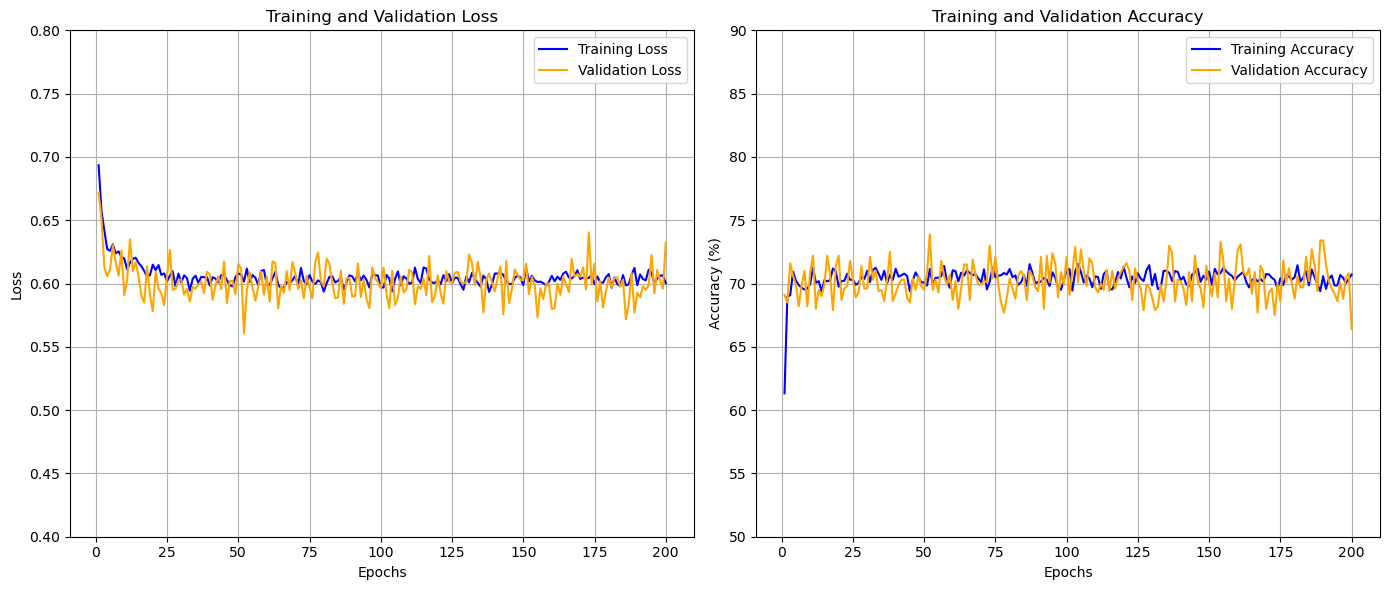

In [26]:
# Plot metrics
my_util.plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, NUM_ITEMS, IMAGE_FILE)

In [27]:
# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
            outputs = model(X_batch.to(dtype=torch.float32).to(device))
        elif MODEL_MODE == "dol1l2":
            outputs, _, _ = model(X_batch.to(dtype=torch.float32).to(device))
        
        predictions = (outputs.squeeze(1) >= 0.5).long()
        test_true_labels.extend(y_batch.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())

In [28]:
# Evaluation metrics
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='binary'  # Use 'macro' for multi-class
)

test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
test_auc_score = roc_auc_score(test_true_labels, test_predictions)
cr = classification_report(test_true_labels, test_predictions)
cm = confusion_matrix(test_true_labels, test_predictions)

In [29]:
test_output = f"""Accuracy Score on test set: {test_acc_score:.2f} %
AUC Score on test set: {test_auc_score:.2f}
Precision: {precision:.4f}
Recall: {recall:.4f}
F1-Score: {f1_score:.4f}

Detailed Classification Report:
{cr}

Confusion Matrix:
{cm}
"""

print(test_output)

Accuracy Score on test set: 70.80 %
AUC Score on test set: 0.71
Precision: 0.7370
Recall: 0.6321
F1-Score: 0.6805

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.78      0.73       508
           1       0.74      0.63      0.68       492

    accuracy                           0.71      1000
   macro avg       0.71      0.71      0.71      1000
weighted avg       0.71      0.71      0.71      1000


Confusion Matrix:
[[397 111]
 [181 311]]



In [30]:
# Save the test output to text file
with open(TEST_FILE, 'w', newline = '') as text_file:
    text_file.write(test_output)

In [31]:
# Training metrics
experiment_results = {
    'train_loss'    : train_losses,
    'train_accuracy': train_accuracies,
    'train_auc'     : train_aucs,
    'val_loss'      : val_losses,
    'val_accuracy'  : val_accuracies,
    'val_auc'       : val_aucs
}

experiment_pl = pl.DataFrame(experiment_results)
experiment_pl.write_csv(TRAINING_FILE)

In [32]:
# Test output
test_results = {
    'test_acc'    : round(test_acc_score, 4),
    'test_auc'    : round(test_auc_score, 4)
}

test_pl = pl.DataFrame(test_results)
test_pl.write_csv(TEST_RESULT_FILE)

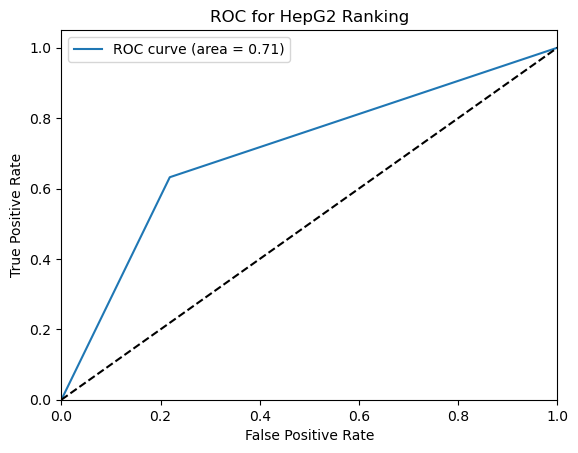

In [33]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC for HepG2 Ranking')
plt.legend()

plt.savefig(ROC_FILE)

plt.show()

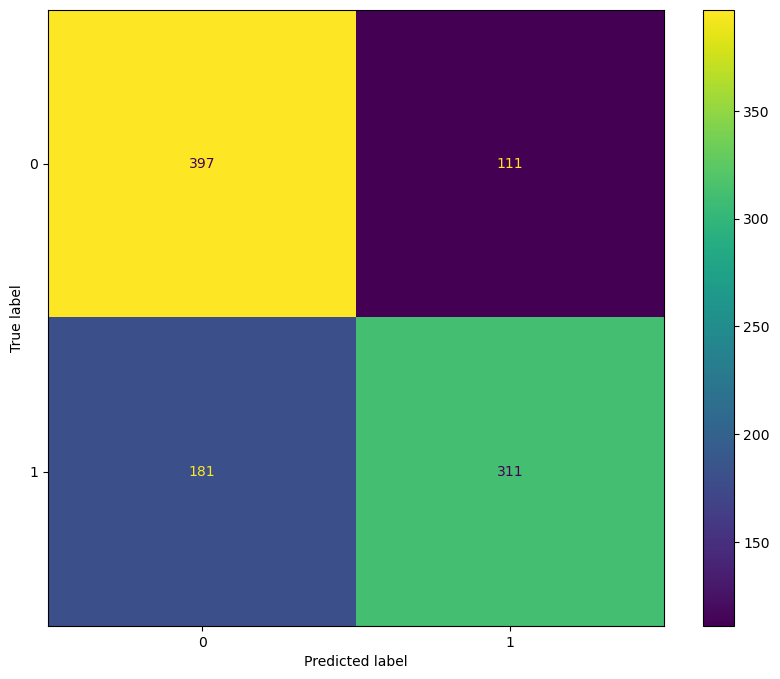

In [34]:
# Plot the confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 8))
cm_display.plot(ax=ax)
plt.savefig(CM_FILE)